# Лабораторная работа №3
**Деревья решений в задачах классификации и регрессии. ROC-кривая**

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             roc_curve, auc, accuracy_score, classification_report)

df = pd.read_csv('processed_titanic.csv')
df[['Sex_male','Embarked_Q','Embarked_S']] = df[['Sex_male','Embarked_Q','Embarked_S']].astype(int)
print(df.shape)
df.head()

(891, 10)


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0.000000,0.0,1.0,0.271174,0.125,0.0,0.014151,1,0,1
1,0.001124,1.0,0.0,0.472229,0.125,0.0,0.139136,0,0,0
2,0.002247,1.0,1.0,0.321438,0.000,0.0,0.015469,0,0,1
3,0.003371,1.0,0.0,0.434531,0.125,0.0,0.103644,0,0,1
4,0.004494,0.0,1.0,0.434531,0.000,0.0,0.015713,1,0,1


## 2. Задача регрессии
Предсказываем непрерывный признак **Fare** с помощью `DecisionTreeRegressor`.

In [16]:
X = df.drop(columns=['Fare','PassengerId'])
y = df['Fare']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

reg = DecisionTreeRegressor(max_depth=3, random_state=42)
reg.fit(X_train, y_train)
y_pred = reg.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)
print(f'MSE = {mse:.5f} , средний квадрат ошибки. Чем меньше, тем лучше. Штрафует большие ошибки сильнее.')
print(f'MAE = {mae:.5f} , cредний модуль ошибки. Интерпретируется как «в среднем ошибаемся на столько-то»')
print(f'R2  = {r2:.4f} , (коэффициент детерминации) — доля дисперсии, объяснённая моделью. R² = 1 — идеально, R² = 0 — модель не лучше среднего, R² < 0 — хуже среднего.')

MSE = 0.00344 , средний квадрат ошибки. Чем меньше, тем лучше. Штрафует большие ошибки сильнее.
MAE = 0.03068 , cредний модуль ошибки. Интерпретируется как «в среднем ошибаемся на столько-то»
R2  = 0.4166 , (коэффициент детерминации) — доля дисперсии, объяснённая моделью. R² = 1 — идеально, R² = 0 — модель не лучше среднего, R² < 0 — хуже среднего.


### Визуализация дерева регрессии

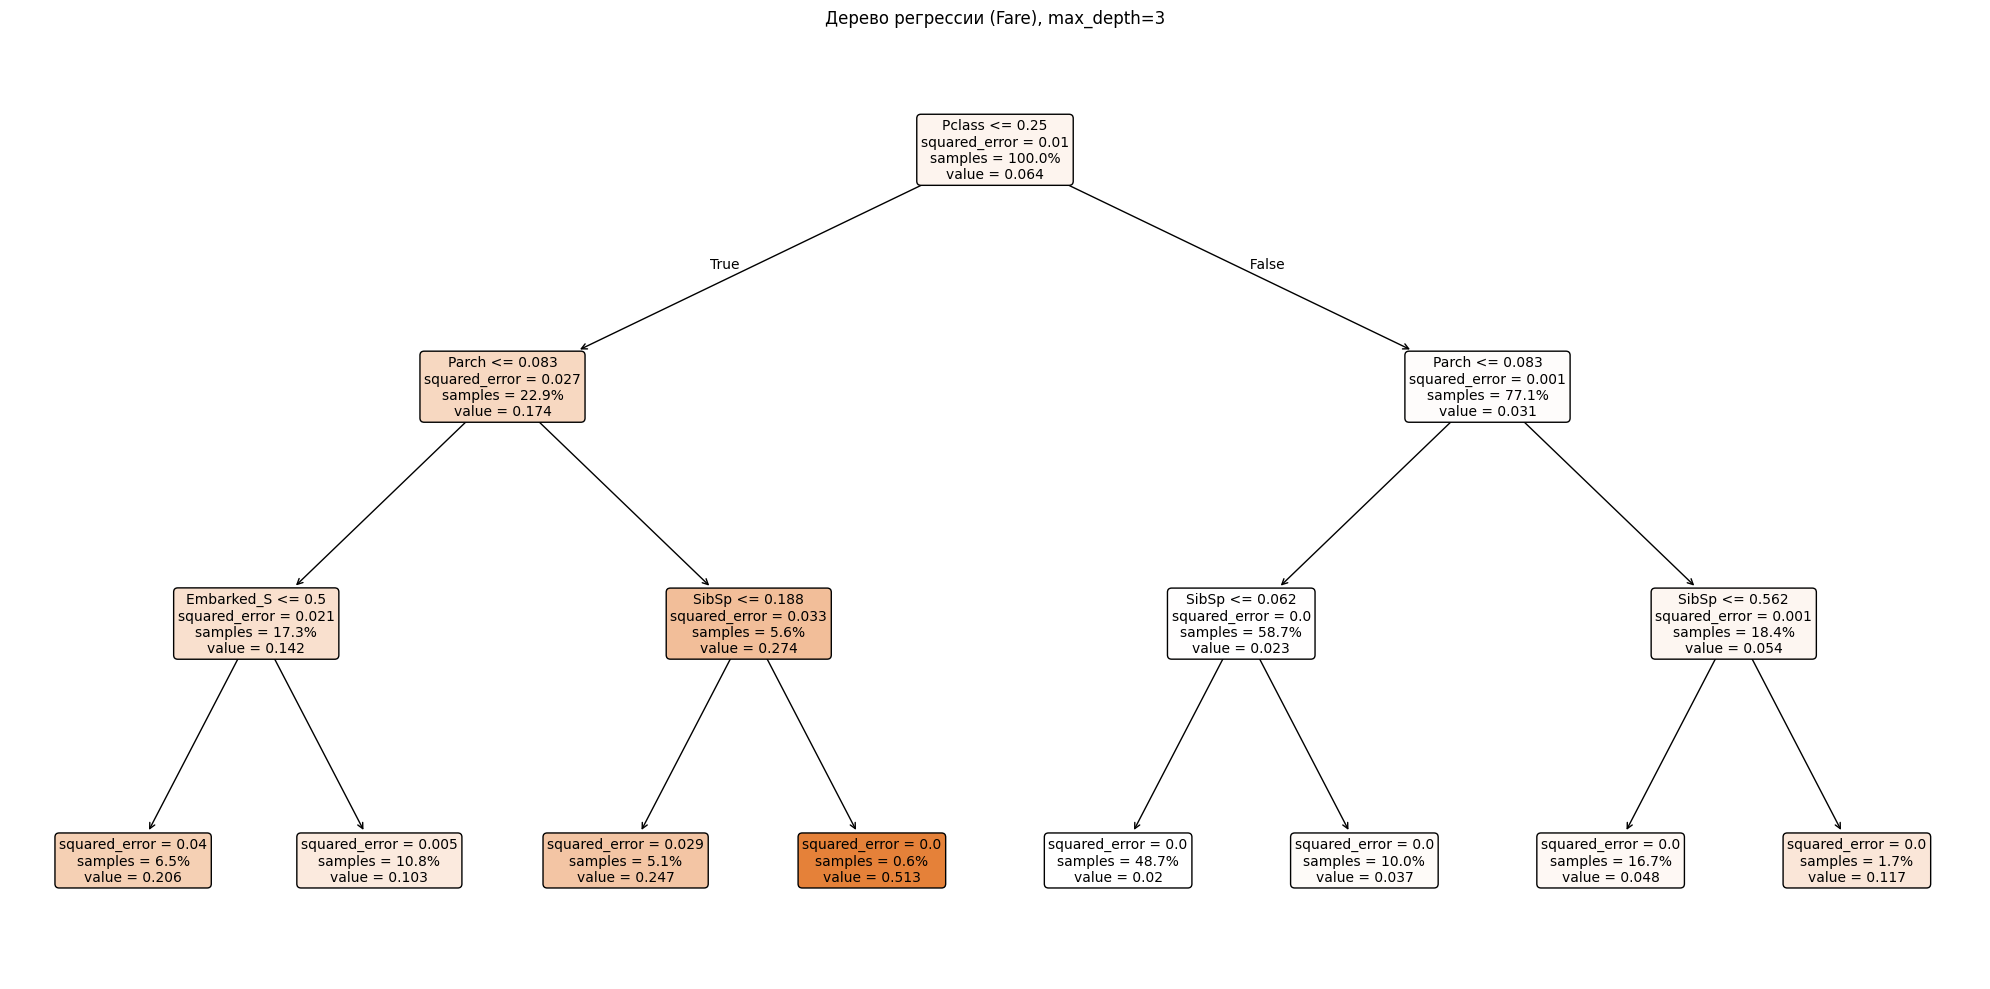

In [17]:
fig, ax = plt.subplots(figsize=(20,10))
plot_tree(reg, feature_names=X.columns, filled=True,
          fontsize=10, rounded=True, proportion=True, ax=ax)
plt.title('Дерево регрессии (Fare), max_depth=3')
plt.tight_layout()
plt.show()

### Истинные vs предсказанные значения

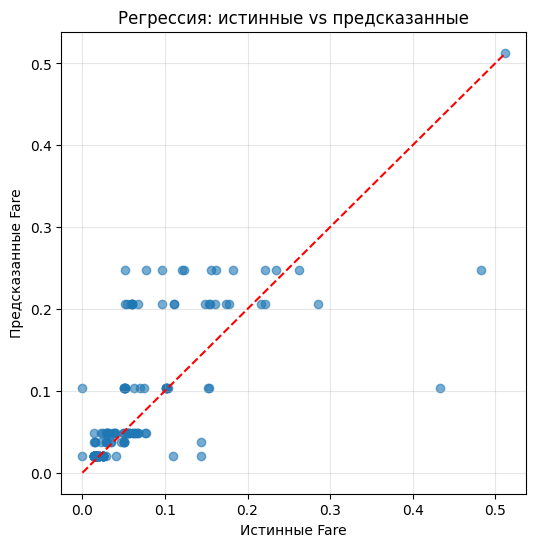

In [18]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Истинные Fare')
plt.ylabel('Предсказанные Fare')
plt.title('Регрессия: истинные vs предсказанные')
plt.grid(alpha=0.3)
plt.show()

## 3. Задача классификации и ROC-кривая
Предсказываем **Survived** с помощью `DecisionTreeClassifier`.

In [19]:
Xc = df.drop(columns=['Survived','PassengerId'])
yc = df['Survived'].astype(int)
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    Xc, yc, test_size=0.2, random_state=42, stratify=yc)

clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(Xc_train, yc_train)

yc_pred  = clf.predict(Xc_test)
yc_proba = clf.predict_proba(Xc_test)[:, 1]

acc = accuracy_score(yc_test, yc_pred)
print(f'Accuracy = {acc:.4f}')
print(classification_report(yc_test, yc_pred))

Accuracy = 0.7654
              precision    recall  f1-score   support

           0       0.77      0.88      0.82       110
           1       0.75      0.58      0.66        69

    accuracy                           0.77       179
   macro avg       0.76      0.73      0.74       179
weighted avg       0.76      0.77      0.76       179



### Дерево классификации

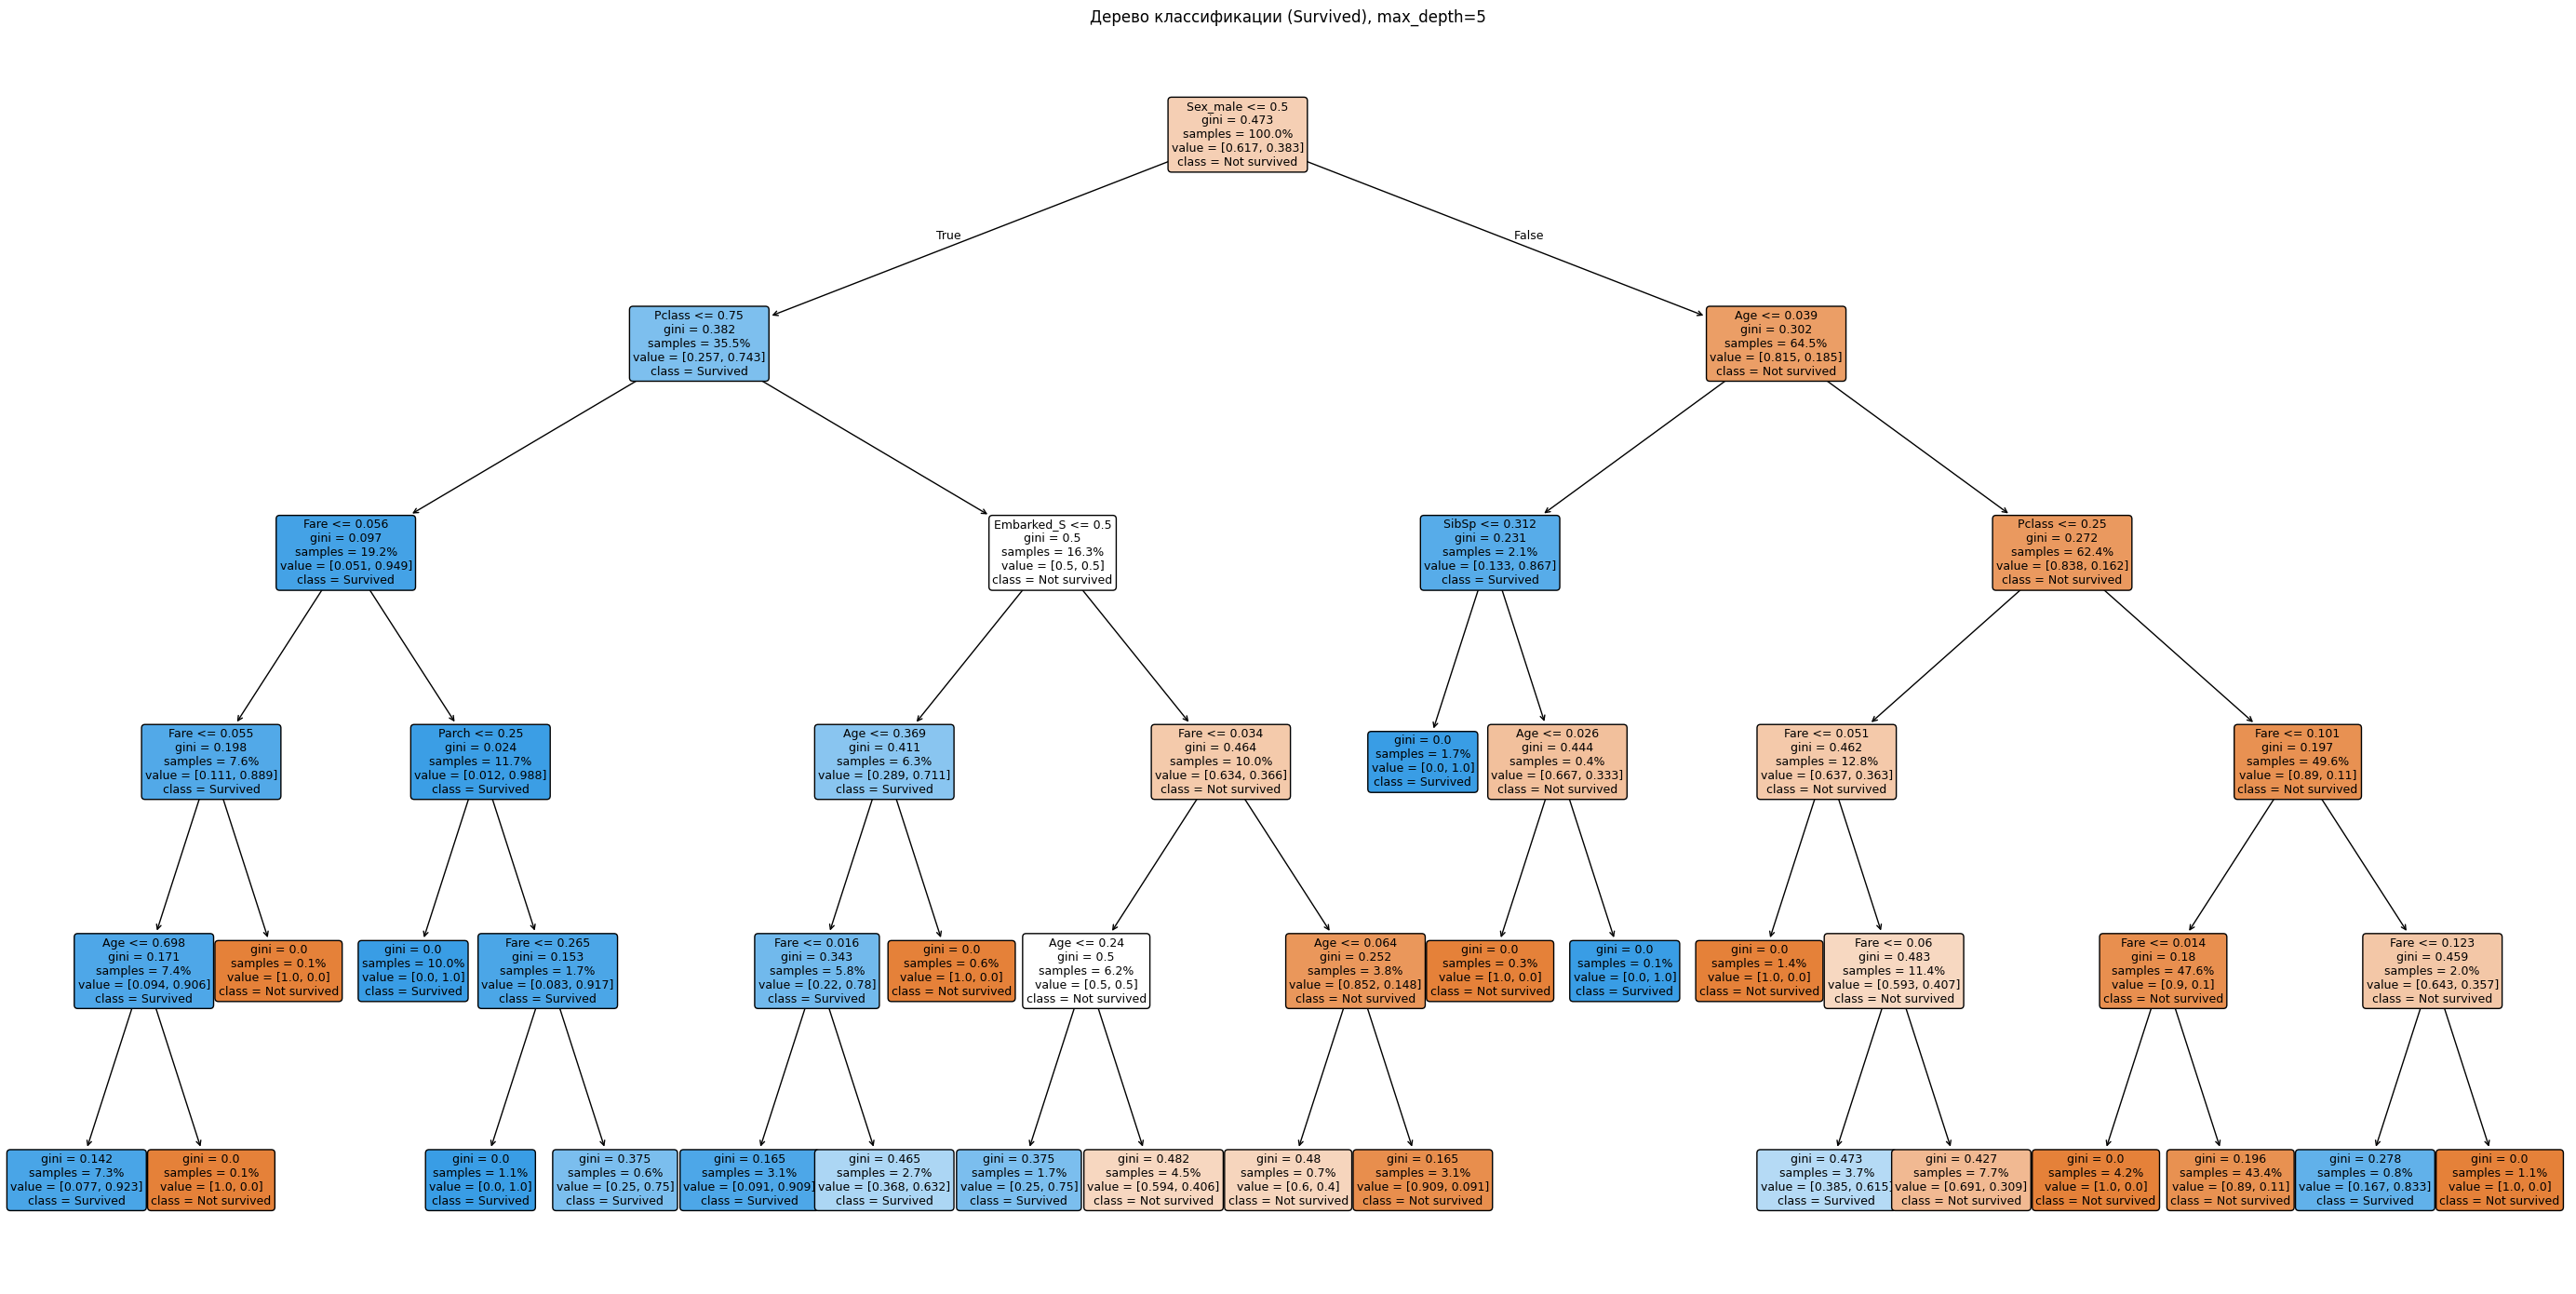

In [20]:
fig, ax = plt.subplots(figsize=(28,14))
plot_tree(clf, feature_names=Xc.columns,
          class_names=['Not survived','Survived'],
          filled=True, fontsize=9, rounded=True, proportion=True, ax=ax)
plt.title('Дерево классификации (Survived), max_depth=5')
plt.tight_layout()
plt.show()

### ROC-кривая и ROC-AUC

ROC-AUC = 0.7971


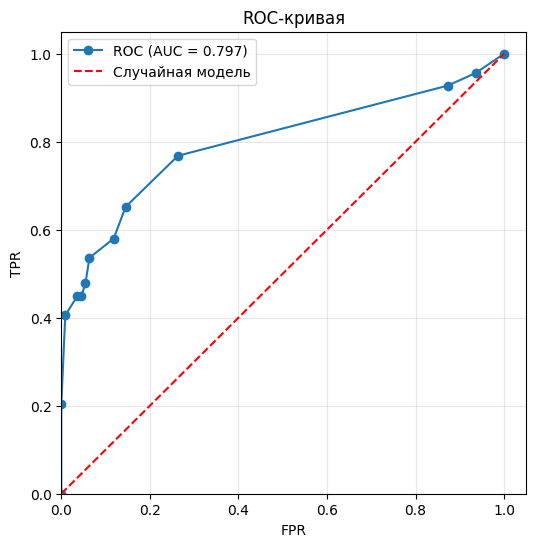

In [21]:
fpr, tpr, thresholds = roc_curve(yc_test, yc_proba)
roc_auc = auc(fpr, tpr)
print(f'ROC-AUC = {roc_auc:.4f}')

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, marker='o', label=f'ROC (AUC = {roc_auc:.3f})')
plt.plot([0,1],[0,1],'r--', label='Случайная модель')
plt.xlim([0,1.05]); plt.ylim([0,1.05])
plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('ROC-кривая')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

## 4. Выводы

- **Регрессия (Fare):** дерево с `max_depth=3` даёт R² ≈ 0.42. Увеличение глубины приводит к переобучению и снижению R² на тесте.
- **Классификация (Survived):** Accuracy ≈ 0.77, ROC-AUC ≈ 0.80 — модель существенно лучше случайной.
- ROC-кривая расположена заметно выше диагонали, что подтверждает хорошую разделяющую способность классификатора.